In [1]:
import json
import numpy as np
import jax.numpy as jnp

from compile_from_dict import numpy_compile, jax_compile
import pandas as pd
import corner
import matplotlib.pyplot as plt

import numpyro, os, json
import numpyro.distributions as dist
import jax.numpy as jnp
from numpyro.infer import Predictive
import arviz as az
import jax

from numpyro import handlers
from numpyro.infer import MCMC, NUTS, Predictive

In [2]:
model_name = 'M4-test'
with open(f'models/{model_name}.json', 'r') as fp:
    model_dict = json.load(fp)

In [3]:
jax_model = jax_compile(model_dict,)

In [4]:
seed = 42

df_full = pd.read_hdf('../M4/grids/Chiara-dnufit.hdf5', key='df') ## edit for your grid!!

df_full['logLPhot'] = np.log10(df_full['LPhot'])

df_full['lognumax'] = np.log10(df_full['numax']*3090)

df_full['logdnufit'] = np.log10(df_full['dnufit'])

df_full['logAge'] = np.log10(df_full['age'])

#### define inputs
inputs = ['massini', 'zini', 'yini', 'alphaMLT', 'logAge', 'eta', 'alphaFe']

#### define outputs
classical_outputs = ['FeH', 'logLPhot', 'Teff']
astero_outputs = ['lognumax', 'logdnufit'] 

outputs = classical_outputs+astero_outputs

df = df_full[inputs+outputs]

df_norm = (df - df.min())/(df.max() - df.min())
df_train = df.sample(frac=0.95, random_state=seed)
df_test_norm = df_norm.drop(df_train.index)
df_test = df.drop(df_train.index)
df_small = df_full.sample(1000)


# Maddy's only

In [32]:
M22 = pd.read_csv('../M4/data/M4RGB_ps/M4_seismicanalysis.csv')
pbjam = pd.read_csv('../M4/data/pbjam-results-dnu-maddy.csv')

M22 = M22.merge(pbjam, on = 'star_id')

M22 = M22[~M22['star_id'].isin(['M4RGB252', 'M4RGB238', 'M4RGB217', 'M4RGB165', 'M4RGB131', 'M4RGB34', 'M4RGB25', 'M4RGB22', 'M4RGB16'])].reset_index()

IDs = M22['star_id']

dnu = M22['dnu_pbjam']
ednu_obs = M22['ednu_pbjam']
ednu_pred = 0.007*dnu
ednu = np.sqrt(ednu_obs**2 + ednu_pred**2)

LPhot = M22['Lum_bol'] + 2
eLPhot_obs = np.sqrt(M22['Lum_bol_err_random']**2 + M22['Lum_bol_err_systematic']**2)
eLPhot_pred = 0.011*LPhot
eLPhot = np.sqrt(eLPhot_obs**2 + eLPhot_pred**2)

Teff = M22['Teff_final'] - 70

maxes_in = df[inputs].max().values
mins_in = df[inputs].min().values
maxes_out = df[outputs].max().values
mins_out = df[outputs].min().values

num_stars = len(Teff)

obs = {'FeH':-1.07*np.ones_like(Teff),  'Teff':Teff.values, 'dnuSer':dnu.values,'logLPhot':np.log10(LPhot.values), 'LPhot':LPhot.values}
unc = {'Teff':Teff.values, 'dnuSer':ednu.values, 'FeH':0.05*np.ones_like(Teff.values), 'logLPhot':eLPhot.values/LPhot.values*1/np.log(10), 'LPhot':eLPhot.values}
unc['Teff'] = 150*np.ones_like(Teff.values)


# Maddy + Marco

In [132]:
M22 = pd.read_csv('../M4/data/M4RGB_ps/M4_seismicanalysis.csv')
pbjam = pd.read_csv('../M4/data/pbjam-results-dnu-maddy.csv')

M22 = M22.merge(pbjam, on = 'star_id')

M22 = M22[~M22['star_id'].isin(['M4RGB252', 'M4RGB238', 'M4RGB217', 'M4RGB165', 'M4RGB131', 'M4RGB34', 'M4RGB25', 'M4RGB22', 'M4RGB16'])].reset_index()

IDs = M22['star_id']

dnu_maddy = M22['dnu_pbjam'].values
ednu_obs_maddy = M22['ednu_pbjam'].values
ednu_pred_maddy = 0.007*dnu_maddy
ednu_maddy = np.sqrt(ednu_obs_maddy**2 + ednu_pred_maddy**2)

LPhot_maddy = M22['Lum_bol'].values
eLPhot_obs_maddy = np.sqrt(M22['Lum_bol_err_random'].values**2 + M22['Lum_bol_err_systematic'].values**2)
eLPhot_pred_maddy = 0.011*LPhot_maddy
eLPhot_maddy = np.sqrt(eLPhot_obs_maddy**2 + eLPhot_pred_maddy**2)

Teff_maddy = M22['Teff_final']

maxes_in = df[inputs].max().values
mins_in = df[inputs].min().values
maxes_out = df[outputs].max().values
mins_out = df[outputs].min().values


T22 = pd.read_csv('../M4/data/T22M08.csv')
pbjam = pd.read_csv('../M4/data/pbjam-results-dnu.csv')

data = T22.merge(pbjam, on = 'WID')

data = data[~data['WID'].isin(['W1763', 'W2034', 'W1912', 'W760',])].reset_index()[:]

IDs = data['WID']

dnu_marco = data['dnu_pbjam'].values
ednu_obs_marco = data['ednu_pbjam'].values
ednu_pred_marco = 0.007*dnu_marco
ednu_marco = np.sqrt(ednu_obs_marco**2 + ednu_pred_marco**2)

LPhot_marco = data['LPhot'].values - 2
eLPhot_obs_marco = data['eLPhot'].values
eLPhot_pred_marco = 0.011*LPhot_marco
eLPhot_marco = np.sqrt(eLPhot_obs_marco**2 + eLPhot_pred_marco**2)

Teff_marco = data['Teff'].values + 70


Teff = np.concat([Teff_maddy, Teff_marco])[0:30]

dnu = np.concat([dnu_maddy, dnu_marco])[0:30]

ednu = np.concat([ednu_maddy, ednu_marco])[0:30]

LPhot = np.concat([LPhot_maddy, LPhot_marco])[0:30]

eLPhot = np.concat([eLPhot_maddy, eLPhot_marco])[0:30]


obs = {'FeH':-1.07*np.ones_like(Teff),  'Teff':Teff, 'dnuSer':dnu,'logLPhot':np.log10(LPhot), 'LPhot':LPhot}
unc = {'Teff':Teff, 'dnuSer':ednu, 'FeH':0.05*np.ones_like(Teff), 'logLPhot':eLPhot/LPhot*1/np.log(10), 'LPhot':eLPhot}
unc['Teff'] = 150*np.ones_like(Teff)


num_stars = len(Teff)

In [133]:
obs_values = np.full((len(outputs) + 3), None)
        
obs_dict = {}
        
for key, value in zip(outputs + ['LPhot', 'numax', 'dnuSer'], obs_values):
    if key not in obs_dict:
        obs_dict[key] = value
    else:
        obs_dict[key].append(value)

In [134]:
def massfromage(age):
    logage = np.log(age)
    return np.exp(-0.3*logage + 2.4)

def lnsigmoid(x, k, mini, spread):
    s = k*(x - mini)/spread
    y = (1 + jnp.exp(-s))
    return -1*jnp.log(y)

def sample_beta(param_name, loc, scale, alpha = 2, beta = 2):

    beta_samp = numpyro.sample(f'{param_name}_beta', dist.Beta(alpha, beta))

    return numpyro.deterministic(param_name, loc + scale*beta_samp)

In [138]:
def shared_2param(uncs,  obs = obs_dict):

    age = sample_beta('age', 8000, 6000, alpha = 2, beta = 2)

    zini = sample_beta('zini', 0.5*0.01756*10**-1.1, 2*0.01756*10**-1.1, alpha = 2, beta = 2) #This is probably far too conservative 

    yini = sample_beta('yini', 0.248, 0.05, alpha = 1.5, beta = 5)

    alphaMLT = sample_beta('alphaMLT', 1.5, 0.8, alpha = 1.5, beta = 1.5)

    eta = sample_beta('eta', 0.0004, 0.29, alpha = 1.5, beta = 1.5)

    alphaFe = sample_beta('alphaFe', 0.31, 0.15, alpha = 5, beta = 5) #Proxy for a normal distribution
    
    with numpyro.plate("star", num_stars):    
   
        tau = sample_beta('tau', 1.0, 0.5, alpha = 2, beta = 2)

        star_age = jnp.stack([age for i in range(num_stars)], axis = 0)

        star_zini = jnp.stack([zini for i in range(num_stars)], axis = 0)
        
        star_yini = jnp.stack([yini for i in range(num_stars)], axis = 0)

        star_aMLT = jnp.stack([alphaMLT for i in range(num_stars)], axis = 0)

        star_eta = jnp.stack([eta for i in range(num_stars)], axis = 0)

        star_aFe = jnp.stack([alphaFe for i in range(num_stars)], axis = 0)

        massini = numpyro.deterministic('massini', tau*jnp.exp(-0.3*jnp.log(star_age) + 2.4)) #I got the values in here from fitting the distribution in the grid and then varying the offset such that its a lower bound (a bit naff, I know)

        numpyro.factor('logfac',lnsigmoid(massini, 10, 0.7, 0.01))

        params_unnorm = jnp.stack([massini, star_zini, star_yini, star_aMLT, jnp.log10(star_age), star_eta, star_aFe], axis = -1)

        params_norm = (params_unnorm - mins_in)/(maxes_in - mins_in)

        pred_norm = jax_model.jit_forward_pass(params_norm)
        
        pred = pred_norm*(maxes_out - mins_out) + mins_out


    FeH = numpyro.sample("FeH", dist.StudentT(df = 10, loc = pred[:, 0], scale = uncs['FeH']), obs=obs['FeH'])
    
    LPhot = numpyro.sample("LPhot", dist.StudentT(df = 10, loc = 10**pred[:, 1], scale = uncs['LPhot']), obs=obs['LPhot'])
    
    Teff = numpyro.sample("Teff", dist.StudentT(df = 10, loc = pred[:, 2], scale = uncs['Teff']), obs=obs['Teff'])

    dnu = numpyro.sample("dnuSer", dist.StudentT(df = 30, loc = 10**(pred[:, 4])/1.0109, scale = uncs['dnuSer']), obs=obs['dnuSer'])

 



In [139]:
num_warmup, num_samples = 10000,8000 
#10000, 8000 works with stars 6, 16
num_chains = 1

sampler = NUTS(shared_2param, target_accept_prob=0.8, find_heuristic_step_size=True, init_strategy=numpyro.infer.init_to_sample) #May be worth trying init_to_sample

mcmc = MCMC(sampler, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)

In [140]:
rng_key = jax.random.PRNGKey(0)

rng_key, rng_key_ = jax.random.split(rng_key)

num_prior_samples = 1000

prior_predictive = Predictive(shared_2param, num_samples=num_prior_samples,)

prior = prior_predictive(rng_key_, \
                         uncs=unc, )

coords = {"star": np.arange(num_stars)}
dims = {}
for key, value in prior.items():
    dims[key] = dim = []
    if value.ndim == 1:
        continue
    if value.shape[-1] == num_stars:
        dim.append("star")

data = az.from_numpyro(prior=prior, coords=coords, dims=dims)

In [ ]:
mcmc.run(jax.random.PRNGKey(0),  uncs=unc, obs=obs)

mcmc.print_summary()

sample:  69%|██████████████████████████████████████████████████████████████▏                           | 12449/18000 [1:18:21<42:57,  2.15it/s, 1023 steps of size 4.03e-04. acc. prob=0.95]

In [115]:
posterior = mcmc.get_samples(group_by_chain=True)

sample_stats = mcmc.get_extra_fields(group_by_chain=True)

rng, key = jax.random.split(jax.random.PRNGKey(0))

posterior_predictive = Predictive(shared_2param, posterior_samples=posterior, parallel=True, batch_ndims=2)

post_obs = posterior_predictive(rng_key, uncs = unc)

sample_stats = mcmc.get_extra_fields(group_by_chain=True)

data += az.from_dict(posterior, sample_stats=sample_stats, coords=coords, dims=dims, )

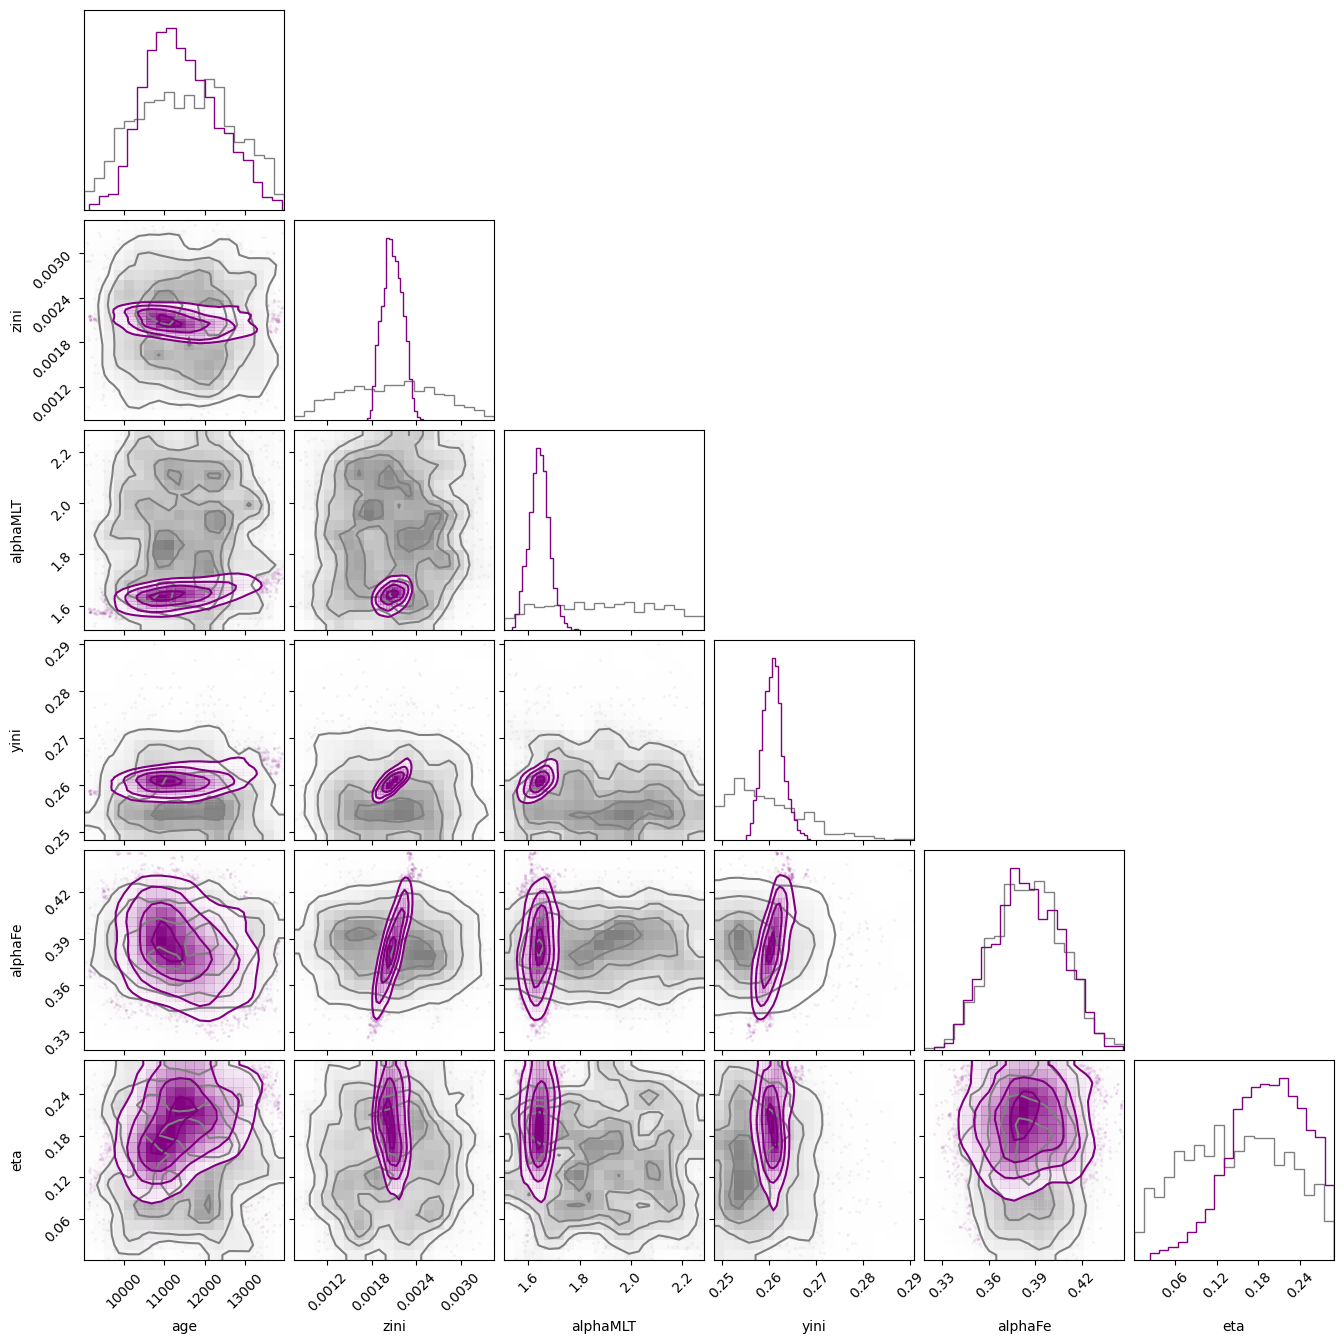

In [116]:
fig = corner.corner(data, group="prior", var_names = ['age', 'zini', 'alphaMLT', 'yini', 'alphaFe', 'eta'], color = 'grey', smooth = True, hist_kwargs={'density':True})
corner.corner(data, group="posterior", var_names = ['age', 'zini', 'alphaMLT', 'yini', 'alphaFe', 'eta'], color = 'purple',  smooth = True, fig = fig, hist_kwargs={'density':True})
plt.show()

In [118]:
np.mean(data['posterior']['age'])

<xarray.DataArray 'age' ()> Size: 8B
array(11420.3821791)

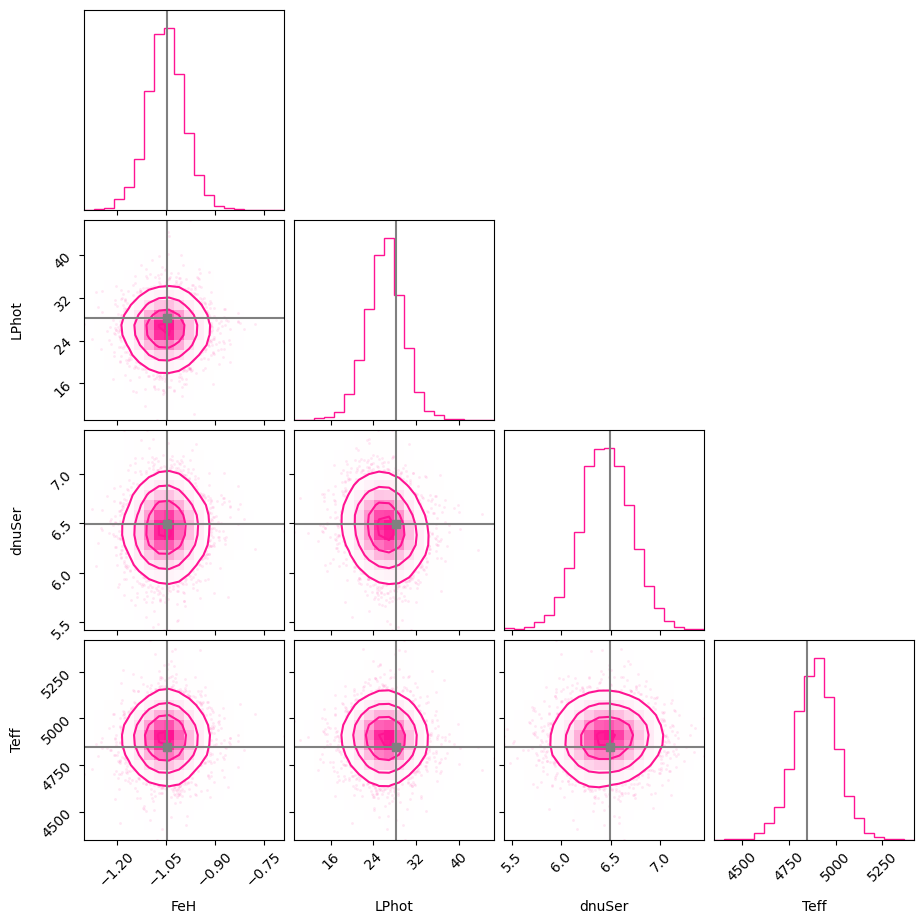

In [60]:
post_pred = az.from_dict(post_obs, coords=coords, dims=dims,)
star = 8
fig = corner.corner(post_pred, group = "posterior", var_names = ['FeH', 'LPhot', 'dnuSer', 'Teff'],  color = 'deeppink', smooth = True, plot_datapoints = True, hist_kwargs={'density':True}, coords = {'star':star}, truths = [FeH.values[star], LPhot.values[star], dnu.values[star], Teff.values[star]], truth_color = 'grey')